# Router Reward & Confidence Analysis

Understanding **why** a model was chosen is crucial. This notebook explores the internal reward scores predicted by the router.

**Goals:**
1. Load the Multitask Reward Router.
2. Inspect the reward distribution for a sample query.
3. Visualize how the router ranks different models.

---

In [1]:
# 1. Setup Paths
import sys
import os
from pathlib import Path

current_dir = Path(os.getcwd())
project_root = current_dir.parent.parent
sys.path.append(str(project_root))

try:
    import artemis_final
    from artemis_final.router.public_api import load_router_from_checkpoint
    print(" Imports successful")
except ImportError as e:
    print(f" Import failed: {e}")

 Imports successful


In [2]:
# 2. Load Reward Router
CHECKPOINT_PATH = project_root / "artemis_final" / "checkpoints" / "best_multitask_router_v1.pt"

router = None
if CHECKPOINT_PATH.exists():
    router = load_router_from_checkpoint("reward", str(CHECKPOINT_PATH), verbose=False)
    print(" Loaded Reward Router")
else:
    print("️ Checkpoint not found.")

 Loaded Reward Router


Selected Model: qwen3_vl_8b_thinking
Rewards:


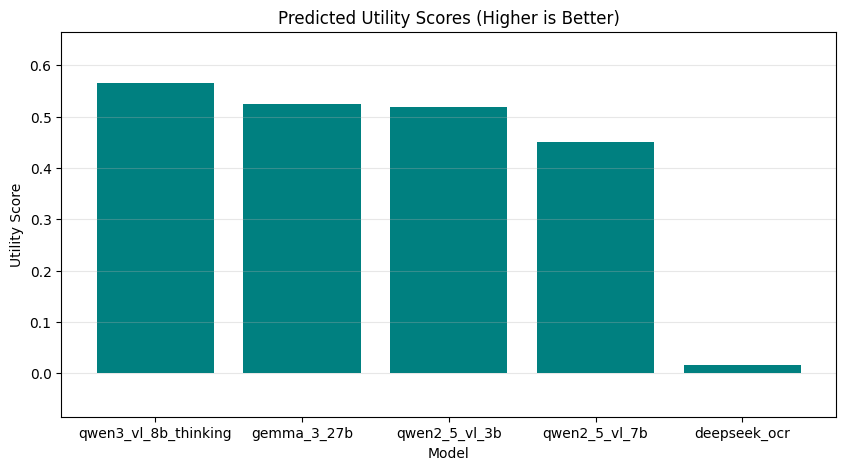

In [3]:
# 3. Run Inference and Visualize Rewards
from PIL import Image
import matplotlib.pyplot as plt

image = Image.new('RGB', (224, 224), color='green')
prompt = "Describe this image exhaustively."

if router:
    decision = router.route(prompt=prompt, image=image, mode="accuracy")
    
    print(f"Selected Model: {decision['chosen_model']}")
    print("Rewards:")
    
    rewards = decision['rewards']
    # Sort for better plotting
    sorted_rewards = dict(sorted(rewards.items(), key=lambda item: item[1], reverse=True))
    
    plt.figure(figsize=(10, 5))
    bars = plt.bar(sorted_rewards.keys(), sorted_rewards.values(), color='teal')
    plt.title("Predicted Utility Scores (Higher is Better)")
    plt.ylabel("Utility Score")
    plt.xlabel("Model")
    plt.ylim(min(rewards.values()) - 0.1, max(rewards.values()) + 0.1)
    plt.grid(axis='y', alpha=0.3)
    plt.show()


In [4]:
# 4. Internal Task Prediction
# The router also predicts what 'task' it thinks the query is (e.g. captioning, ocr, etc)
# Note: This requires accessing the raw model output if not exposed in route()
# In the current simple route() API, we might not see task logits directly, but they are computed internally.
print("Task prediction analysis is available via internal model inspection if needed.")

Task prediction analysis is available via internal model inspection if needed.
